In [ ]:
## CUSTOMER CHURN  PREDICTION 

In [7]:

# 1. Install Libraries 
# ================================
#!pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap imbalanced-learn


# 2. Import Libraries
# ================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap


# 3. Load Dataset
# ================================
df = pd.read_csv(r"C:\Users\91993\Downloads\archive (1)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean column names (important)
df.columns = df.columns.str.strip()

print("Columns:", df.columns)


# 4. Data Preprocessing
# ================================

# Drop customerID safely (no error if not present)
df.drop(columns=["customerID"], errors='ignore', inplace=True)

# Convert TotalCharges to numeric (important fix)
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


# 5. Split Data
# ================================
X = df.drop("Churn", axis=1)
y = df["Churn"]


# 6. Handle Imbalance (SMOTE)
# ================================
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)


# 7. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# ================================
# 8. Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Columns: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [8]:
# ================================
# 9. Models
# ================================

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1021
           1       0.80      0.85      0.82      1049

    accuracy                           0.81      2070
   macro avg       0.81      0.81      0.81      2070
weighted avg       0.81      0.81      0.81      2070

ROC-AUC: 0.8955453120317004


In [9]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))



===== Random Forest =====
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1021
           1       0.86      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070

ROC-AUC: 0.9298385011050122


In [10]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\n===== XGBoost =====")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))



===== XGBoost =====
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1021
           1       0.84      0.85      0.85      1049

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070

ROC-AUC: 0.9275014962246586


C:\Users\91993\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


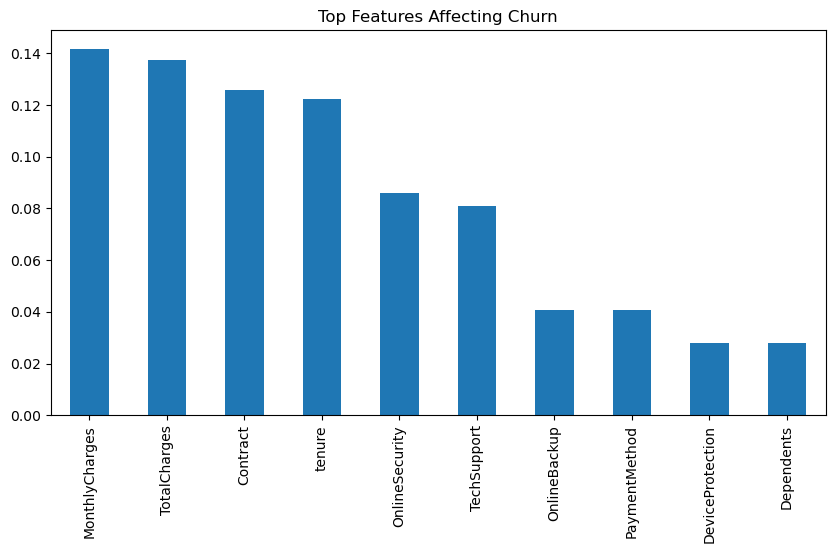

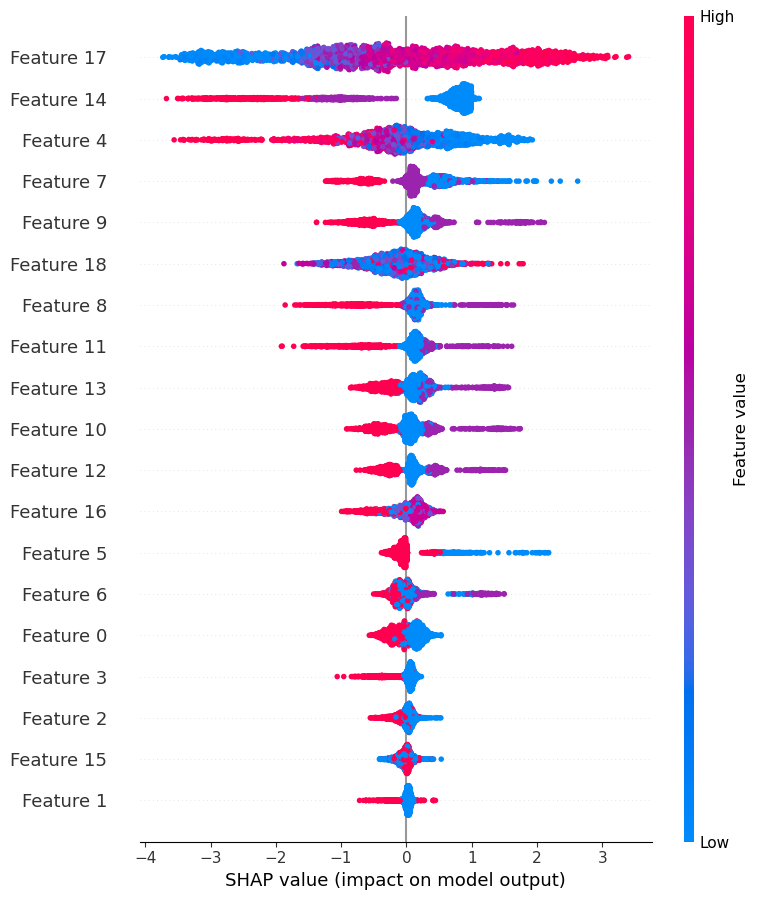


New Customer Prediction: Churn


In [11]:

# ================================
# 11. SHAP (Interpretability)
# ================================
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# ================================
# 12. Predict New Customer
# ================================
sample = X_test[0].reshape(1, -1)

prediction = xgb.predict(sample)
print("\nNew Customer Prediction:",
      "Churn" if prediction[0]==1 else "No Churn")

In [5]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Accuracy: 0.8130434782608695
Random Forest Accuracy: 0.857487922705314


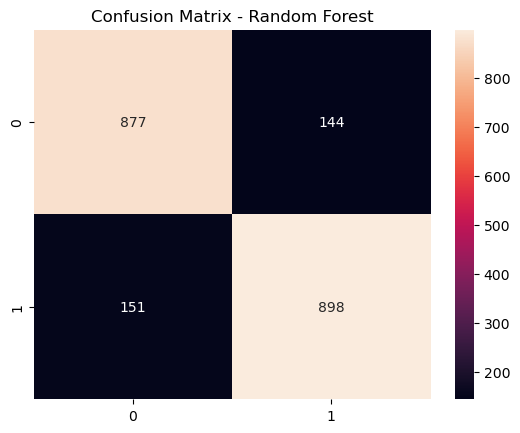

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [ ]:
877 (TN)
Predicted No Churn
Actually No Churn
Correct

144 (FP)
 Predicted Churn
 Actually No Churn
 Wrong (false alarm)

151 (FN)
 Predicted No Churn
 Actually Churn
 Wrong (missed customer)

898 (TP)
 Predicted Churn
 Actually Churn
 Correct

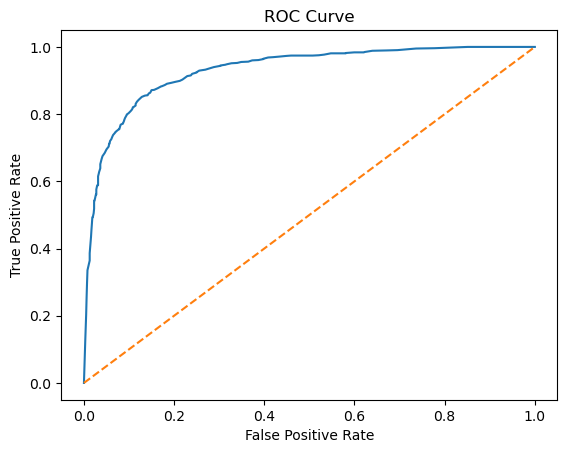

ROC-AUC: 0.9298385011050122


In [7]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

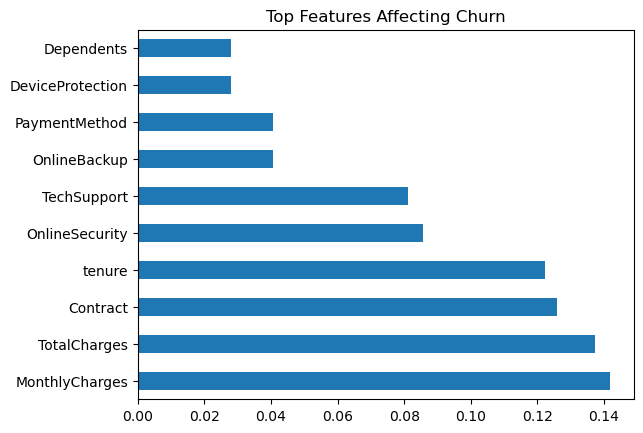

In [9]:
## importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.show()